In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

import scipy.sparse as sparse

In [2]:
def coshCorrel(nt, Energy, pivot,dimt):
    num = np.exp(-nt*Energy)+np.exp((nt-dimt)*Energy)
    denom = np.exp(-pivot*Energy)+np.exp((pivot-dimt)*Energy)
    return num/denom

In [3]:
with open('configs/50kSteps.pkl', 'rb') as f:
    a1 = pickle.load(f)

In [10]:
bIn = 1000
skp = 50
correl1 = sim.distillation.correlStats(a1, burnIn=bIn,autocorrSkip=skp,nVec=1)
correl4 = sim.distillation.correlStats(a1, burnIn=bIn,autocorrSkip=skp,nVec=4)
correl8 = sim.distillation.correlStats(a1, burnIn=bIn,autocorrSkip=skp,nVec=8)

configs:   0%|          | 0/980 [00:00<?, ?it/s]

configs:   0%|          | 0/980 [00:00<?, ?it/s]

configs:   0%|          | 0/980 [00:00<?, ?it/s]

In [11]:
piv = 4
fitMass1 = sim.distillation.correlMassExtract(correl1,fitT=[piv,28],diagCov=True)
fitMass4 = sim.distillation.correlMassExtract(correl4,fitT=[piv,28],diagCov=True)
fitMass8 = sim.distillation.correlMassExtract(correl8,fitT=[piv,28],diagCov=True)

In [18]:
fitMass1

array([5.44249027e-01, 5.18773284e-04])

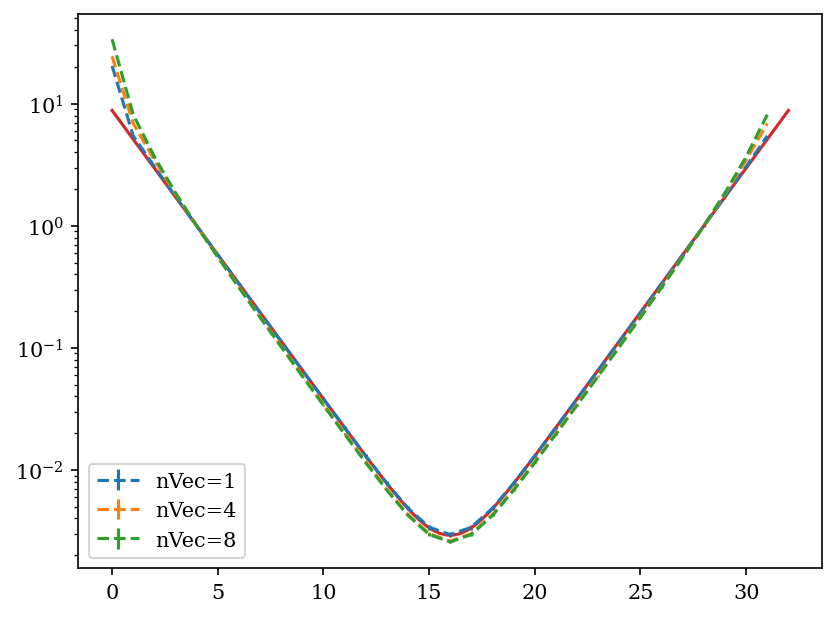

In [17]:
plt.figure(dpi=150)
plt.errorbar(x=np.arange(a1.dimt),y=correl1[0]/correl1[0][piv],yerr=correl1[1]/correl1[0][piv],label="nVec=1",ls="--")
plt.errorbar(x=np.arange(a1.dimt),y=correl4[0]/correl4[0][piv],yerr=correl4[1]/correl4[0][piv],label="nVec=4",ls="--")
plt.errorbar(x=np.arange(a1.dimt),y=correl8[0]/correl8[0][piv],yerr=correl8[1]/correl8[0][piv],label="nVec=8",ls="--")

nts = np.linspace(0,a1.dimt,100)
plt.plot(nts,coshCorrel(nts,fitMass1[0]*a1.a,piv,a1.dimt))

plt.semilogy()
plt.legend()

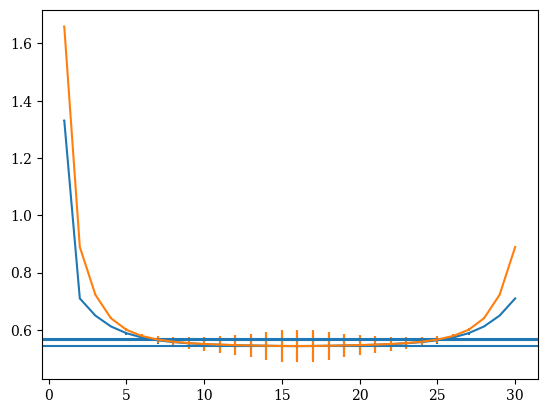

In [16]:
effMass4 = sim.analysis.effectiveMassProp(correl4,coshExpr=True)
effMass16 = sim.analysis.effectiveMassProp(correl16,coshExpr=True)

plt.errorbar(x=np.arange(1,a1.dimt-1),y=effMass4[0]/a1.a,yerr=effMass4[1]/a1.a)
plt.errorbar(x=np.arange(1,a1.dimt-1),y=effMass16[0]/a1.a,yerr=effMass16[1]/a1.a)

plt.axhline(fitMass1[0])
plt.axhline(fitMass4[0])
plt.axhline(fitMass8[0])